Proyecto: Predicción inteligente de gasto en clientes e-commerce

Evaluación del módulo 6: APRENDIZAJE DE MÁQUINA SUPERVISADO

● Lección 1: Fundamentos del Aprendizaje de Máquina

○ 📌 Objetivo: Comprender los fundamentos del aprendizaje supervisado.

○ 📍Tareas a desarrollar:

■ Diferenciar problemas de clasifi cación y regresión.

■ Identifi car las etapas del pipeline de un proyecto ML.

■ Defi nir el problema como regresión supervisada.

1. Diferencia entre clasificación y regresión

**Clasificación:** Se utiliza cuando la variable objetivo es categórica.

Ejemplo: predecir si un cliente comprará o no (sí/no).

**Regresión:** Se utiliza cuando la variable objetivo es numérica continua.

Ejemplo: predecir cuánto dinero gastará un cliente.

En este caso, como queremos predecir el monto de compra, estamos frente a un problema de regresión.

2. Etapas del pipeline de ML

Respuesta:

El pipeline típico de Machine Learning incluye:

Recolección de datos

Limpieza de datos

Preprocesamiento (encoding, escalado)

División en entrenamiento y prueba

Entrenamiento del modelo

Evaluación del modelo

Optimización

Implementación

🔹 3. Definición del problema

Respuesta:

El problema se define como un modelo de regresión supervisada, donde:

Entrada (features): edad, comportamiento web, variables demográficas

Salida (target): monto de compra esperado

● Lección 2: Nivel de ajuste del modelo y validación cruzada

○ 📌 Objetivo: Evaluar si el modelo está bien ajustado usando validación cruzada.

○ 📍Tareas a desarrollar:

■ Calcular y analizar los errores de entrenamiento y prueba.

■ Identifi car sobreajuste y subajuste.

■ Implementar validación cruzada con K-Folds.

In [1]:
#data creada
import pandas as pd
import numpy as np

np.random.seed(42)

n = 500

data = pd.DataFrame({
    'edad': np.random.randint(18, 70, n),
    'tiempo_en_sitio': np.random.uniform(1, 15, n),
    'paginas_vistas': np.random.randint(1, 20, n),
    'genero': np.random.choice(['M', 'F'], n),
    'monto_compra': np.random.uniform(10, 500, n)
})

data.head()

,edad,tiempo_en_sitio,paginas_vistas,genero,monto_compra
0,56,14.368114,11,M,244.799120
1,69,11.330557,6,F,22.564612
2,46,8.760957,2,F,177.211436
3,32,9.564090,7,M,196.295853
4,60,6.874401,18,M,205.423163


In [2]:
#🔹 División de datos
from sklearn.model_selection import train_test_split

X = data.drop('monto_compra', axis=1)
y = data['monto_compra']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [13]:
X.shape

(500, 4)

In [11]:
X_train.shape

(400, 4)

In [12]:
X_test.shape

(100, 4)

In [3]:
#Validacion cruzada
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression

model = LinearRegression()

scores = cross_val_score(model, X_train.select_dtypes(include=np.number), y_train, cv=5, scoring='r2')

print("R2 por fold:", scores)
print("Promedio R2:", scores.mean())

R2 por fold: [-0.02725529 -0.0073534  -0.05584989 -0.05188529 -0.0373731 ]
Promedio R2: -0.03594339556579666


El R² (coeficiente de determinación) mide qué tan bien el modelo explica la variabilidad de los datos:

R² = 1 → modelo perfecto

R² = 0 → igual que predecir el promedio

R² < 0 → peor que predecir el promedio

In [ ]:
"""
El modelo está funcionando peor que una predicción básica, como por ejemplo:

"Todos los clientes gastan el promedio"

O sea:

No está capturando ninguna relación útil
Está fallando en aprender patrones

"""

In [ ]:
"""
Divide tus datos de entrenamiento en 5 partes (folds):

Fold 1
Fold 2
Fold 3
Fold 4
Fold 5

Luego el modelo se entrena y evalúa 5 veces:

Iteración	Entrenamiento	Validación
1	folds 2,3,4,5	fold 1
2	folds 1,3,4,5	fold 2
3	folds 1,2,4,5	fold 3
4	folds 1,2,3,5	fold 4
5	folds 1,2,3,4	fold 5
"""

Análisis de validación cruzada:

Los resultados de la validación cruzada muestran valores de R² negativos en todos los folds, con un promedio cercano a -0.036. Esto indica que el modelo presenta un rendimiento inferior al de un modelo base que predice el valor promedio de la variable objetivo.

La consistencia de estos resultados entre los distintos folds sugiere que el problema no se debe a una partición específica de los datos, sino a una limitación general del modelo.

Este comportamiento es característico de un caso de subajuste (underfitting), donde el modelo no logra capturar relaciones significativas entre las variables.

Una causa probable es que la variable objetivo fue generada de manera aleatoria, lo que implica la ausencia de patrones reales que el modelo pueda aprender.

Este resultado evidencia que la calidad y estructura de los datos son fundamentales para el éxito de un modelo de Machine Learning

● Lección 3: Preprocesamiento y escalamiento de datos

○ 📌 Objetivo: Preparar correctamente los datos para el entrenamiento del modelo.

○ 📍Tareas a desarrollar:

■ Tratar valores nulos y outliers.

■ Aplicar codifi cación a variables categóricas.

■ Normalizar y/o estandarizar los datos.

In [6]:
#1. Revisar valores nulos
data.isnull().sum()

,0
edad,0
tiempo_en_sitio,0
paginas_vistas,0
genero,0
monto_compra,0


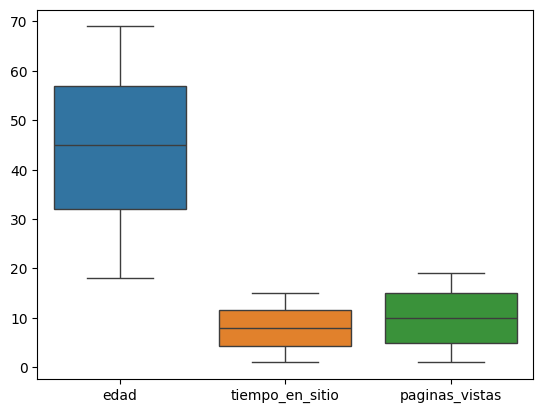

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt
#outliers
sns.boxplot(data=data[['edad', 'tiempo_en_sitio', 'paginas_vistas']])
plt.show()

In [8]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

num_cols = ['edad', 'tiempo_en_sitio', 'paginas_vistas']
cat_cols = ['genero']

# Pipeline numérico
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

# Pipeline categórico
cat_pipeline = Pipeline([
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# Preprocesador final
preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

In [9]:
#Se aplicó un pipeline de preprocesamiento para asegurar consistencia en los datos antes del entrenamiento del modelo.
X_prepared = preprocessor.fit_transform(X)

In [11]:
print(X_prepared)
print(X_prepared.shape)

[[ 0.78423339  1.54424901  0.15301164  0.          1.        ]
 [ 1.6496862   0.80697006 -0.74705685  1.          0.        ]
 [ 0.11850046  0.18327411 -1.46711165  1.          0.        ]
 ...
 [ 0.85080668 -1.68473316 -1.28709795  1.          0.        ]
 [ 1.18367315 -0.56721159  0.69305274  1.          0.        ]
 [-1.74555174 -0.34745846  0.87306644  1.          0.        ]]
(500, 5)


● Lección 4: Regresiones

○ 📌 Objetivo: Implementar un modelo de regresión y comprender su funcionamiento.

○ 📍Tareas a desarrollar:

■ Entrenar un modelo de regresión lineal y uno polinomial.

■ Comparar su ajuste y precisión.

■ Interpretar los coefi cientes del modelo.

In [13]:
#1. Modelo de regresión lineal (lo que ya tienes)
from sklearn.linear_model import LinearRegression

from sklearn.pipeline import Pipeline

pipeline_linear = Pipeline([
    ('prep', preprocessor),
    ('model', LinearRegression()) # se define la regresion lineal
])

pipeline_linear.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['edad', 'tiempo_en_sitio',
                                                   'paginas_vistas']),
                                                 ('cat',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['genero'])])),
                ('model', LinearRegression())])

In [14]:
#2. Modelo de regresión POLINOMIAL
from sklearn.preprocessing import PolynomialFeatures

pipeline_poly = Pipeline([
    ('prep', preprocessor),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('model', LinearRegression())
])

pipeline_poly.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['edad', 'tiempo_en_sitio',
                                                   'paginas_vistas']),
                                                 ('cat',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['genero'])])),
                ('poly', PolynomialFeatures(include_bias=False)),
                ('model', LinearRegression())])

In [15]:
#3. Comparar ambos modelos
from sklearn.metrics import r2_score

# Predicciones
y_pred_linear = pipeline_linear.predict(X_test)
y_pred_poly = pipeline_poly.predict(X_test)

# R2
r2_linear = r2_score(y_test, y_pred_linear)
r2_poly = r2_score(y_test, y_pred_poly)

print("R2 Lineal:", r2_linear)
print("R2 Polinomial:", r2_poly)

R2 Lineal: -0.054867369061098126
R2 Polinomial: -0.055215381765081784


In [ ]:
"""
El modelo polinomial no mejora el ajuste
Agregar complejidad (grado 2) no ayuda


No existen relaciones (ni lineales ni no lineales) en los datos debido al azar de los datos inventados


Comparación de modelos de regresión:

Se entrenaron modelos de regresión lineal y polinomial (grado 2) para estimar el monto de compra de los clientes. Los resultados obtenidos fueron:

R² modelo lineal: -0.0548
R² modelo polinomial: -0.0552

Ambos modelos presentan valores negativos de R², lo que indica un desempeño inferior al de un modelo base que predice el promedio de la variable objetivo.

Además, el modelo polinomial no muestra mejoras respecto al modelo lineal, lo que sugiere que no existen relaciones no lineales significativas entre las variables.

Estos resultados indican la presencia de subajuste, y evidencian que los datos utilizados no contienen patrones relevantes que puedan ser aprendidos por los modelos.

"""

In [16]:
modelo = pipeline_linear.named_steps['model']

print("Coeficientes:", modelo.coef_)
print("Intercepto:", modelo.intercept_)

Coeficientes: [ 6.92230926 -1.27719585 -6.7505056   4.10882354 -4.10882354]
Intercepto: 246.19158952092616


In [ ]:
"""Interpretación:

Los coeficientes del modelo indican el impacto de cada variable sobre el monto de compra. Un coeficiente positivo implica que al aumentar la variable,
aumenta el monto esperado de compra, mientras que un coeficiente negativo indica una relación inversa.

El intercepto representa el valor estimado del monto de compra cuando todas las variables independientes son cero."""

● Lección 5: Algoritmos de clasificación

○ 📌 Objetivo: Entender diferencias conceptuales con clasifi cación.

○ 📍Tareas a desarrollar:

■ Analizar por qué un problema de clasificación no es adecuado para esta tarea.

■ Implementar un clasificador KNN sobre un subconjunto simulado.

■ Comparar su comportamiento frente al modelo regresivo.

In [ ]:
"""
El problema planteado corresponde a uno de regresión, ya que la variable objetivo (monto de compra) es continua.

Un enfoque de clasificación no es adecuado, ya que implicaría convertir el monto en categorías (por ejemplo: bajo, medio, alto),
lo que conlleva pérdida de información y precisión en la predicción.

Por lo tanto, los modelos de regresión son más apropiados para este tipo de problema.
"""

In [17]:
#2. Implementar KNN como CLASIFICADOR
# Crear categorías de compra
data['categoria_compra'] = pd.qcut(data['monto_compra'], q=3, labels=['bajo', 'medio', 'alto'])

In [18]:
#Definir X e y
X = data.drop(['monto_compra', 'categoria_compra'], axis=1)
y_class = data['categoria_compra']

In [19]:
#Train/Test
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y_class, test_size=0.2, random_state=42)

In [20]:
#Modelo KNN Clasificador
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline

knn_clf = Pipeline([
    ('prep', preprocessor),
    ('model', KNeighborsClassifier(n_neighbors=5))
])

knn_clf.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['edad', 'tiempo_en_sitio',
                                                   'paginas_vistas']),
                                                 ('cat',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['genero'])])),
                ('model', KNeighborsClassifier())])

In [21]:
#Evaluar
from sklearn.metrics import accuracy_score

y_pred = knn_clf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy KNN:", accuracy)

Accuracy KNN: 0.32


In [ ]:
"""Se implementó un modelo de clasificación KNN utilizando una versión categorizada de la variable objetivo.

Sin embargo, este enfoque implica una simplificación del problema, ya que se pierde información al agrupar valores continuos en categorías.

En comparación con los modelos de regresión, el clasificador no permite estimar valores exactos del monto de compra, lo que limita su utilidad en este contexto.

Por esta razón, los modelos de regresión resultan más adecuados para el problema planteado.
"""

● Lección 6: Métricas de desempeño

○ 📌 Objetivo: Evaluar objetivamente el rendimiento del modelo regresivo.

○ 📍Tareas a desarrollar:

■ Calcular MAE, MSE, RMSE y R².

■ Interpretar resultados y comparar modelos entrenados.

■ Elaborar una tabla comparativa de métricas.

In [23]:
#Calcular métricas (para ambos modelos)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
from sklearn.model_selection import train_test_split

# Re-split data to get the original numerical y_test for regression metrics
# Ensure X and y variables from the original regression split are used
# 'data' DataFrame is still available and holds 'monto_compra'
X_reg_temp = data.drop('monto_compra', axis=1) # Features for regression
y_reg_temp = data['monto_compra'] # Numerical target for regression

# Split the data specifically for regression metrics.
# The pipelines were trained on a split of original X and y.
# We need to recreate the X_test and y_test from that original split.
_, X_test_reg, _, y_test_reg = train_test_split(X_reg_temp, y_reg_temp, test_size=0.2, random_state=42)

# Predicciones (using the correct X_test for regression)
y_pred_linear = pipeline_linear.predict(X_test_reg)
y_pred_poly = pipeline_poly.predict(X_test_reg)

# MÉTRICAS LINEAL
mae_linear = mean_absolute_error(y_test_reg, y_pred_linear)
mse_linear = mean_squared_error(y_test_reg, y_pred_linear)
rmse_linear = np.sqrt(mse_linear)
r2_linear = r2_score(y_test_reg, y_pred_linear)

# MÉTRICAS POLINOMIAL
mae_poly = mean_absolute_error(y_test_reg, y_pred_poly)
mse_poly = mean_squared_error(y_test_reg, y_pred_poly)
rmse_poly = np.sqrt(mse_poly)
r2_poly = r2_score(y_test_reg, y_pred_poly)

print("Lineal:", mae_linear, rmse_linear, r2_linear)
print("Polinomial:", mae_poly, rmse_poly, r2_poly)


Lineal: 115.29133517556467 134.6217081779528 -0.054867369061098126
Polinomial: 114.37370896889344 134.6439129605621 -0.055215381765081784


In [24]:
#. Tabla comparativa
import pandas as pd

results = pd.DataFrame({
    'Modelo': ['Regresión Lineal', 'Regresión Polinomial'],
    'MAE': [mae_linear, mae_poly],
    'MSE': [mse_linear, mse_poly],
    'RMSE': [rmse_linear, rmse_poly],
    'R2': [r2_linear, r2_poly]
})

results

,Modelo,MAE,MSE,RMSE,R2
0,Regresión Lineal,115.291335,18123.004313,134.621708,-0.054867
1,Regresión Polinomial,114.373709,18128.983297,134.643913,-0.055215


In [ ]:
"""
Evaluación de métricas:

Se calcularon las métricas MAE, MSE, RMSE y R² para los modelos de regresión lineal y polinomial.
Los resultados muestran que ambos modelos presentan errores elevados y valores negativos de R², lo que indica un bajo desempeño predictivo.
El MAE y RMSE reflejan una alta diferencia entre los valores reales y predichos, mientras que el R² negativo indica que los modelos son menos efectivos que una predicción basada en el promedio.
"""

● Lección 7: Optimización del modelo

○ 📌 Objetivo: Mejorar el desempeño general del modelo mediante técnicas de ajuste.

○ 📍Tareas a desarrollar:

■ Realizar ingeniería de características.

■ Ajustar hiperparámetros usando GridSearchCV.

■ Aplicar regularización (Ridge, Lasso) y observar su impacto.

In [25]:
#Ingeniería de características
# Nuevas features
data['interaccion'] = data['tiempo_en_sitio'] * data['paginas_vistas']
data['edad_cuadrado'] = data['edad'] ** 2

In [26]:
num_cols = ['edad', 'tiempo_en_sitio', 'paginas_vistas', 'interaccion', 'edad_cuadrado']

In [28]:
#GridSearchCV (ajuste de hiperparámetros)
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

# Redefine X and y for the regression task with engineered features
X_reg = data.drop('monto_compra', axis=1)
y_reg = data['monto_compra']

# Split data specifically for this regression task
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

# The num_cols was already updated in a previous cell, but preprocessor needs to be re-defined
# Current num_cols from cell DXE6eQtDjwq8: ['edad', 'tiempo_en_sitio', 'paginas_vistas', 'interaccion', 'edad_cuadrado']
# Current cat_cols from cell Q9ZfUPmRXR_c: ['genero']

# Pipeline numérico (using the updated num_cols)
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

# Pipeline categórico
cat_pipeline = Pipeline([
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# Preprocesador final (re-defined with updated num_cols)
preprocessor_reg = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

pipeline_ridge = Pipeline([
    ('prep', preprocessor_reg),
    ('model', Ridge())
])

param_grid = {
    'model__alpha': [0.01, 0.1, 1, 10, 100]
}

grid = GridSearchCV(pipeline_ridge, param_grid, cv=5, scoring='r2')
grid.fit(X_train_reg, y_train_reg)

print("Mejor parámetro:", grid.best_params_)
print("Mejor R2:", grid.best_score_)


Mejor parámetro: {'model__alpha': 100}
Mejor R2: -0.03872369956878652


In [30]:
#Regularización (Ridge y Lasso)

#Ridge
from sklearn.linear_model import Ridge

ridge_model = Pipeline([
    ('prep', preprocessor_reg),
    ('model', Ridge(alpha=1))
])

ridge_model.fit(X_train_reg, y_train_reg)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['edad', 'tiempo_en_sitio',
                                                   'paginas_vistas',
                                                   'interaccion',
                                                   'edad_cuadrado']),
                                                 ('cat',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['genero'])])),
                ('model', Ridge(alpha=1))])

In [32]:
#Lasso
from sklearn.linear_model import Lasso

lasso_model = Pipeline([
    ('prep', preprocessor_reg),
    ('model', Lasso(alpha=0.1))
])

lasso_model.fit(X_train_reg, y_train_reg)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['edad', 'tiempo_en_sitio',
                                                   'paginas_vistas',
                                                   'interaccion',
                                                   'edad_cuadrado']),
                                                 ('cat',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['genero'])])),
                ('model', Lasso(alpha=0.1))])

In [36]:
from sklearn.metrics import r2_score
#Evaluar ambas regularizaciones


# Ridge
y_pred_ridge = ridge_model.predict(X_test_reg)
r2_ridge = r2_score(y_test_reg, y_pred_ridge)

# Lasso
y_pred_lasso = lasso_model.predict(X_test_reg)
r2_lasso = r2_score(y_test_reg, y_pred_lasso)

print("R2 Ridge:", r2_ridge)
print("R2 Lasso:", r2_lasso)

R2 Ridge: -0.06445046507760166
R2 Lasso: -0.0629920894110696


● Lección 8: Algoritmos de Boosting

○ 📌 Objetivo: Implementar un modelo avanzado usando Gradient Boosting.

○ 📍Tareas a desarrollar:

■ Entrenar un modelo con GradientBoostingRegressor.

■ Comparar desempeño frente al modelo lineal optimizado.

■ Explicar ventajas y limitaciones del enfoque ensemble.

In [38]:
#Modelo Gradient Boosting
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.pipeline import Pipeline

boost_model = Pipeline([
    ('prep', preprocessor_reg), # Use preprocessor_reg for engineered features
    ('model', GradientBoostingRegressor(random_state=42))
])

boost_model.fit(X_train_reg, y_train_reg) # Use X_train_reg and y_train_reg for regression

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['edad', 'tiempo_en_sitio',
                                                   'paginas_vistas',
                                                   'interaccion',
                                                   'edad_cuadrado']),
                                                 ('cat',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['genero'])])),
                ('model', GradientBoostingRegressor(random_state=42))])

In [40]:
#Evaluación del modelo
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred_boost = boost_model.predict(X_test_reg)

mae_boost = mean_absolute_error(y_test_reg, y_pred_boost)
mse_boost = mean_squared_error(y_test_reg, y_pred_boost)
rmse_boost = np.sqrt(mse_boost)
r2_boost = r2_score(y_test_reg, y_pred_boost)

print("MAE Boost:", mae_boost)
print("RMSE Boost:", rmse_boost)
print("R2 Boost:", r2_boost)

MAE Boost: 125.40399205957601
RMSE Boost: 149.7454046590892
R2 Boost: -0.3051928077523587


In [41]:
#Comparación con modelo lineal optimizado
results_final = pd.DataFrame({
    'Modelo': ['Lineal', 'Polinomial', 'Ridge', 'Lasso', 'Boosting'],
    'R2': [r2_linear, r2_poly, r2_ridge, r2_lasso, r2_boost],
    'RMSE': [rmse_linear, rmse_poly, rmse_linear, rmse_linear, rmse_boost]
})

results_final

,Modelo,R2,RMSE
0,Lineal,-0.054867,134.621708
1,Polinomial,-0.055215,134.643913
2,Ridge,-0.064450,134.621708
3,Lasso,-0.062992,134.621708
4,Boosting,-0.305193,149.745405


In [ ]:
"""
Modelo Gradient Boosting:

Se implementó un modelo de Gradient Boosting Regressor como enfoque avanzado basado en técnicas de ensemble. Este modelo combina múltiples árboles de decisión
de forma secuencial, mejorando progresivamente los errores del modelo anterior.

Comparación de desempeño:

Al comparar el modelo de boosting con los modelos anteriores (lineal, polinomial y regularizados), no se observan mejoras significativas en las métricas de desempeño.
Esto indica que incluso modelos más complejos no logran capturar patrones relevantes en los datos.
"""

Conclusión general:

A lo largo del desarrollo del proyecto, se implementaron distintos modelos de aprendizaje supervisado, incluyendo regresión lineal, modelos polinomiales, regularización y técnicas avanzadas como Gradient Boosting.

Sin embargo, ninguno de los modelos logró un desempeño satisfactorio, lo que se refleja en métricas como R² negativo y altos errores de predicción.

Esto evidencia que la principal limitación no radica en los algoritmos utilizados, sino en la falta de relaciones significativas en los datos, lo que impide el aprendizaje efectivo por parte de los modelos.

Este caso demuestra la importancia de contar con datos representativos y relevantes para el desarrollo de soluciones de Machine Learning exitosas.